# Chi-square, MLE, and Linear Regression


We will:
- visualize how normal random variables lead to the $\chi^2$ and $F$ distributions,
- understand degrees of freedom through simulation,
- see maximum likelihood estimation (MLE) in action,
- connect least squares with parameter estimation in linear regression.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(7)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def finish_axis(ax, title, xlabel, ylabel="Density"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


## Part 1A. Squaring a standard normal random variable

If $X \sim N(0, 1)$ and we define $Y = X^2$, then $Y$ follows a chi-square distribution with 1 degree of freedom:

$$
Y \sim \chi^2_1.
$$

The main geometric change is easy to see:
- negative and positive values of $X$ both map to positive values of $Y$,
- small values stay common,
- large values become a long right tail.


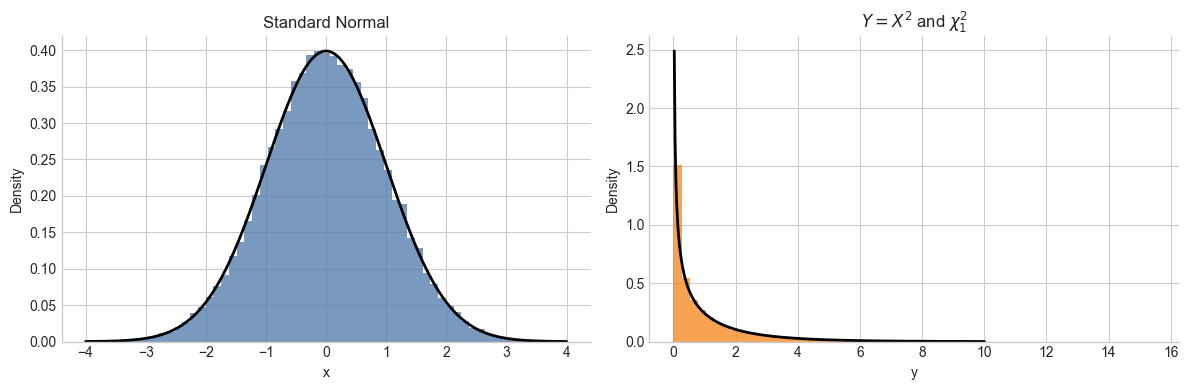

In [3]:
x = rng.normal(loc=0, scale=1, size=50_000)
y = x ** 2

x_grid = np.linspace(-4, 4, 400)
y_grid = np.linspace(0, 10, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(x, bins=60, density=True, alpha=0.75, color="#4C78A8")
axes[0].plot(x_grid, stats.norm.pdf(x_grid), color="black", lw=2)
finish_axis(axes[0], "Standard Normal", "x")

axes[1].hist(y, bins=60, density=True, alpha=0.75, color="#F58518")
axes[1].plot(y_grid, stats.chi2.pdf(y_grid, df=1), color="black", lw=2)
finish_axis(axes[1], r"$Y = X^2$ and $\chi^2_1$", "y")

plt.tight_layout()
plt.show()


## Part 1B. Sum of squares gives a chi-square distribution

If $X_1, \dots, X_k$ are independent standard normal random variables, then

$$
Y = \sum_{i=1}^{k} X_i^2 \sim \chi^2_k.
$$

As $k$ grows:
- the center of the distribution moves to the right,
- the shape becomes less skewed,
- the distribution starts to look more symmetric.


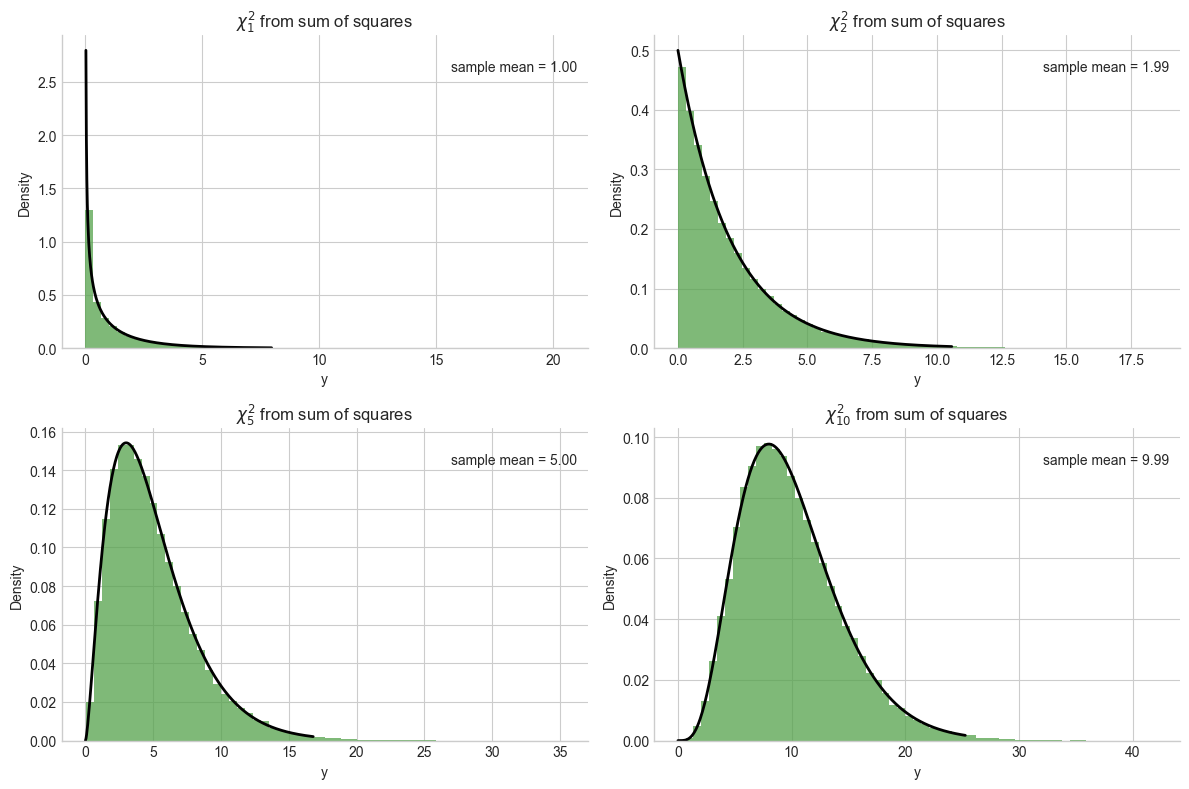

In [4]:
ks = [1, 2, 5, 10]
draws = 60_000
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, k in zip(axes.ravel(), ks):
    samples = rng.normal(size=(draws, k))
    y = np.sum(samples ** 2, axis=1)

    grid = np.linspace(0, np.quantile(y, 0.995), 400)
    ax.hist(y, bins=60, density=True, alpha=0.75, color="#54A24B")
    ax.plot(grid, stats.chi2.pdf(grid, df=k), color="black", lw=2)
    finish_axis(ax, rf"$\chi^2_{{{k}}}$ from sum of squares", "y")
    ax.text(0.98, 0.92, f"sample mean = {y.mean():.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10)

plt.tight_layout()
plt.show()


## Part 1C. Ratio of scaled chi-square variables gives an $F$ distribution

Let

$$
U_1 = \sum_{i=1}^{d_1} X_i^2, \qquad
U_2 = \sum_{j=1}^{d_2} Y_j^2
$$

with independent standard normal samples. Then

$$
F = \frac{U_1 / d_1}{U_2 / d_2}
$$

follows an $F(d_1, d_2)$ distribution.

This distribution is always positive and often has a strong right tail.


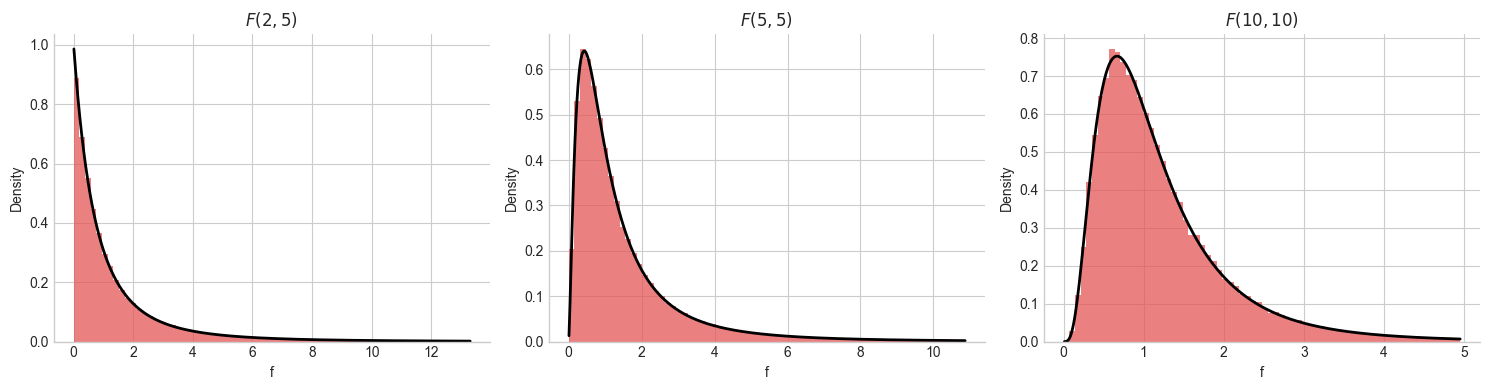

In [5]:
df_pairs = [(2, 5), (5, 5), (10, 10)]
draws = 80_000
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (d1, d2) in zip(axes, df_pairs):
    u1 = np.sum(rng.normal(size=(draws, d1)) ** 2, axis=1)
    u2 = np.sum(rng.normal(size=(draws, d2)) ** 2, axis=1)
    f_values = (u1 / d1) / (u2 / d2)

    upper = np.quantile(f_values, 0.99)
    grid = np.linspace(0.01, upper, 400)

    ax.hist(f_values, bins=70, range=(0, upper), density=True, alpha=0.75, color="#E45756")
    ax.plot(grid, stats.f.pdf(grid, dfn=d1, dfd=d2), color="black", lw=2)
    finish_axis(ax, rf"$F({d1}, {d2})$", "f")

plt.tight_layout()
plt.show()


## Part 1D. Degrees of freedom in sample variance

Suppose $X_1, \dots, X_n \sim N(\mu, \sigma^2)$.

Compare these two quantities:

$$
S_1 = \sum_{i=1}^{n} (X_i - \mu)^2, \qquad
S_2 = \sum_{i=1}^{n} (X_i - \bar{X})^2.
$$

The key difference is that $\bar{X}$ is estimated from the data, so one degree of freedom is used up.

When $\sigma^2 = 1$:
- $S_1 \sim \chi^2_n$,
- $S_2 \sim \chi^2_{n-1}$.


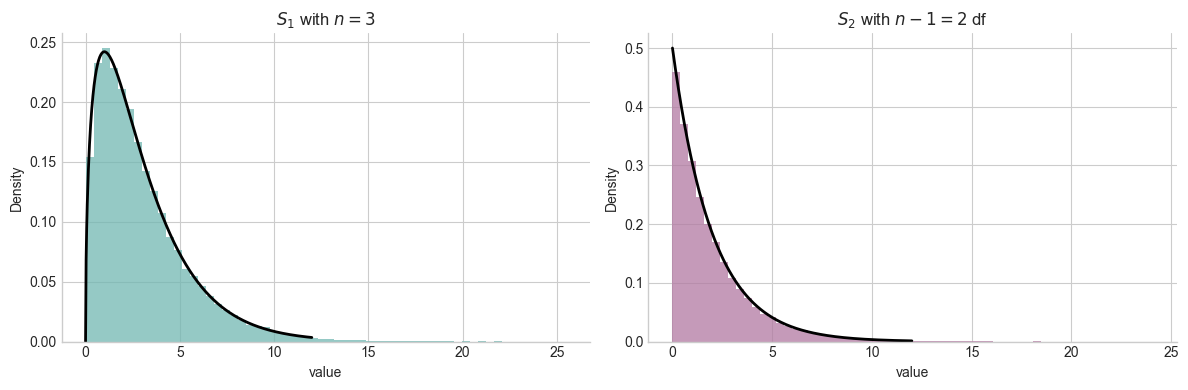

Mean of S1: 2.987
Mean of S2: 1.994


In [6]:
n = 3
mu = 2.0
sigma = 1.0
draws = 60_000

samples = rng.normal(loc=mu, scale=sigma, size=(draws, n))
s1 = np.sum((samples - mu) ** 2, axis=1)
s2 = np.sum((samples - samples.mean(axis=1, keepdims=True)) ** 2, axis=1)

grid = np.linspace(0, 12, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(s1, bins=60, density=True, alpha=0.75, color="#72B7B2")
axes[0].plot(grid, stats.chi2.pdf(grid, df=n), color="black", lw=2)
finish_axis(axes[0], rf"$S_1$ with $n={n}$", "value")

axes[1].hist(s2, bins=60, density=True, alpha=0.75, color="#B279A2")
axes[1].plot(grid, stats.chi2.pdf(grid, df=n - 1), color="black", lw=2)
finish_axis(axes[1], rf"$S_2$ with $n-1={n-1}$ df", "value")

plt.tight_layout()
plt.show()

print(f"Mean of S1: {s1.mean():.3f}")
print(f"Mean of S2: {s2.mean():.3f}")


## Part 1E. Transformations of a one-dimensional random variable

Starting from one normal random variable $X \sim N(0, 1)$, different transformations create very different shapes:
- $X^2$ gives a chi-square-like shape,
- $|X|$ gives a folded distribution,
- $e^X$ gives a log-normal distribution with a long right tail.

This is a good reminder that **the transformation matters just as much as the original variable**.


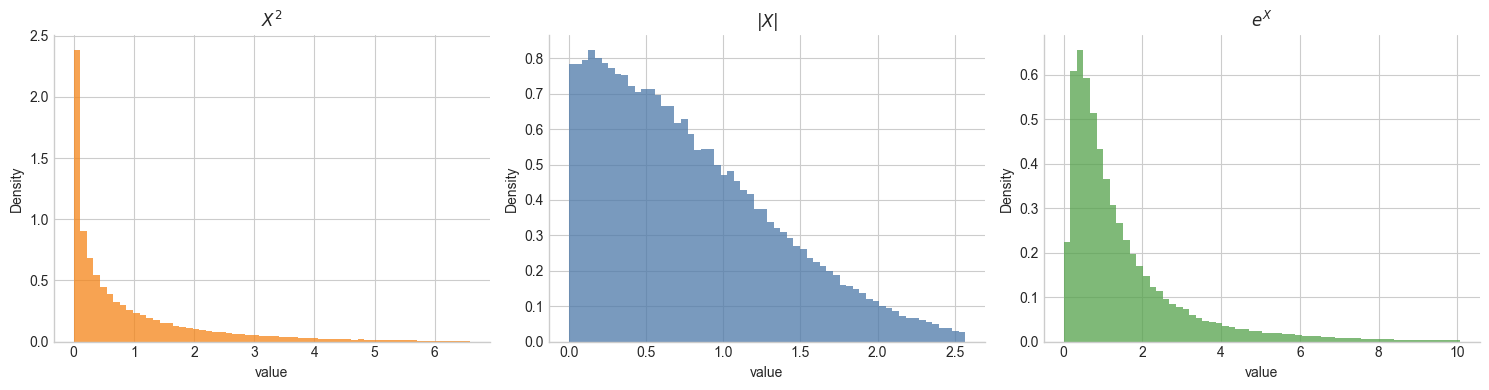

In [7]:
x = rng.normal(size=80_000)
transforms = {
    r"$X^2$": x ** 2,
    r"$|X|$": np.abs(x),
    r"$e^X$": np.exp(x),
}
colors = ["#F58518", "#4C78A8", "#54A24B"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, values), color in zip(axes, transforms.items(), colors):
    upper = np.quantile(values, 0.99)
    ax.hist(values, bins=60, range=(0, upper), density=True, alpha=0.75, color=color)
    finish_axis(ax, label, "value")

plt.tight_layout()
plt.show()


## Part 2. MLE for the mean of a Gaussian distribution

Assume

$$
X_1, \dots, X_n \sim N(\mu, \sigma^2)
$$

and suppose $\sigma^2$ is known.

We will:
- generate data with a known true mean,
- compute the log-likelihood for many candidate values of $\mu$,
- identify the maximizing value,
- compare it with the sample mean.

The theory says the MLE of $\mu$ is the sample mean.


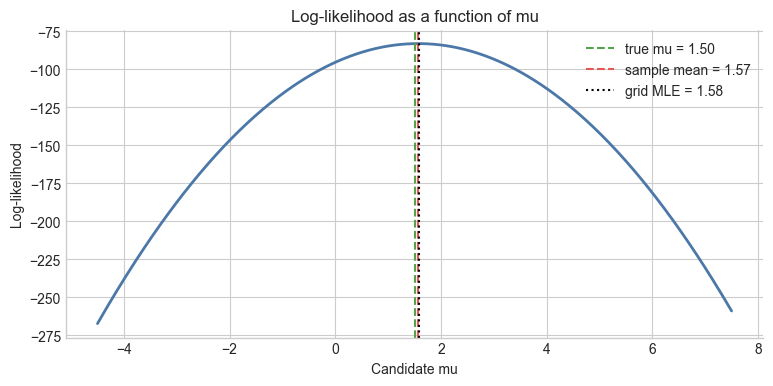

Sample mean: 1.5693
Grid-search MLE: 1.5752


In [8]:
true_mu = 1.5
sigma = 2.0
n = 40

data = rng.normal(loc=true_mu, scale=sigma, size=n)
sample_mean = data.mean()

mu_grid = np.linspace(true_mu - 3 * sigma, true_mu + 3 * sigma, 400)
log_likelihood = np.array([
    stats.norm.logpdf(data, loc=mu, scale=sigma).sum()
    for mu in mu_grid
])

mle_mu = mu_grid[np.argmax(log_likelihood)]

plt.figure(figsize=(9, 4))
plt.plot(mu_grid, log_likelihood, color="#4C78A8", lw=2)
plt.axvline(true_mu, color="#54A24B", linestyle="--", label=f"true mu = {true_mu:.2f}")
plt.axvline(sample_mean, color="#E45756", linestyle="--", label=f"sample mean = {sample_mean:.2f}")
plt.axvline(mle_mu, color="black", linestyle=":", label=f"grid MLE = {mle_mu:.2f}")
plt.title("Log-likelihood as a function of mu")
plt.xlabel("Candidate mu")
plt.ylabel("Log-likelihood")
plt.legend()
plt.show()

print(f"Sample mean: {sample_mean:.4f}")
print(f"Grid-search MLE: {mle_mu:.4f}")


## Part 3. MLE for an exponential distribution

Suppose

$$
X_1, \dots, X_n \sim \text{Exponential}(\beta)
$$

with density

$$
f(x) = \beta e^{-\beta x}, \qquad x > 0.
$$

Here $\beta$ is the **rate** parameter. The theory says

$$
\hat{\beta}_{\text{MLE}} = \frac{1}{\bar{X}}.
$$

We will verify this numerically.


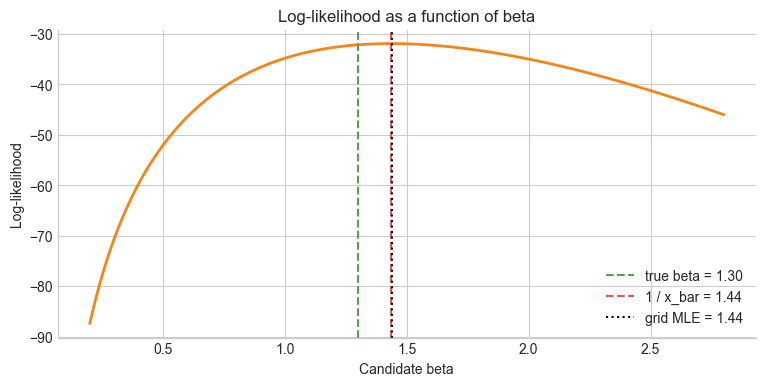

1 / sample mean: 1.4360
Grid-search MLE: 1.4381


In [9]:
true_beta = 1.3
n = 50

data = rng.exponential(scale=1 / true_beta, size=n)
beta_grid = np.linspace(0.2, 2.8, 400)
log_likelihood = n * np.log(beta_grid) - beta_grid * data.sum()

mle_beta = beta_grid[np.argmax(log_likelihood)]
reciprocal_mean = 1 / data.mean()

plt.figure(figsize=(9, 4))
plt.plot(beta_grid, log_likelihood, color="#F58518", lw=2)
plt.axvline(true_beta, color="#54A24B", linestyle="--", label=f"true beta = {true_beta:.2f}")
plt.axvline(reciprocal_mean, color="#E45756", linestyle="--", label=f"1 / x_bar = {reciprocal_mean:.2f}")
plt.axvline(mle_beta, color="black", linestyle=":", label=f"grid MLE = {mle_beta:.2f}")
plt.title("Log-likelihood as a function of beta")
plt.xlabel("Candidate beta")
plt.ylabel("Log-likelihood")
plt.legend()
plt.show()

print(f"1 / sample mean: {reciprocal_mean:.4f}")
print(f"Grid-search MLE: {mle_beta:.4f}")


## Part 4. Linear regression through least squares

Consider the model

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i,
\qquad \varepsilon_i \sim N(0, \sigma^2).
$$

We will:
- generate synthetic data,
- compute the sum of squared errors on a grid of $(\beta_0, \beta_1)$ values,
- find the best pair,
- visualize both the fitted line and the error contour.

This links estimation to optimization: least squares chooses the parameter values that minimize total error.


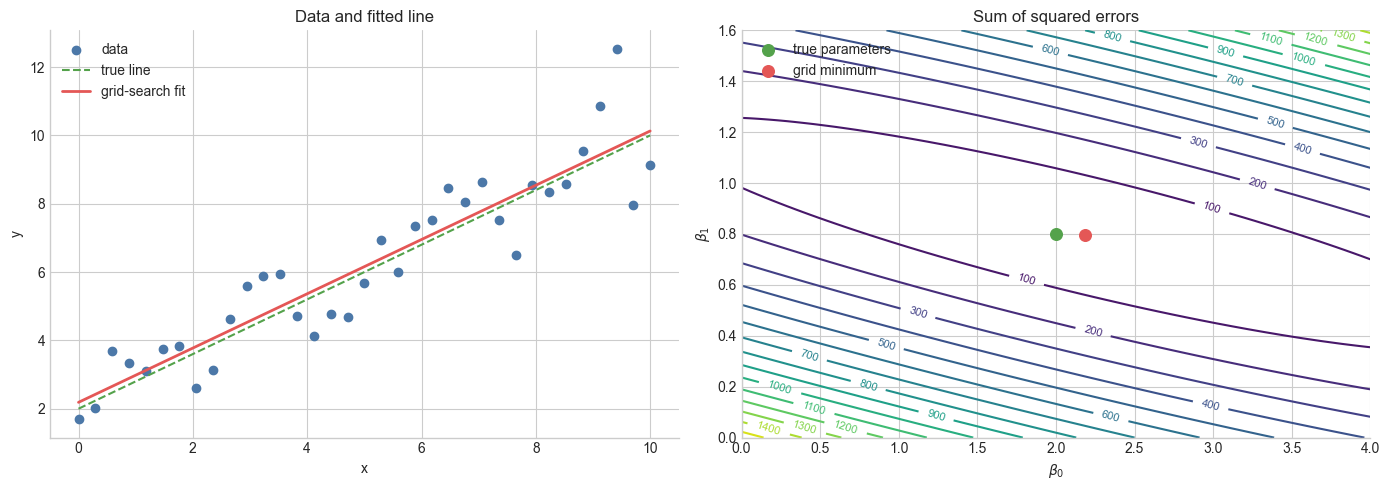

Grid-search estimate: beta0 = 2.187, beta1 = 0.794
OLS estimate:         beta0 = 2.179, beta1 = 0.797


In [10]:
true_beta0 = 2.0
true_beta1 = 0.8
sigma = 1.2
n = 35

x = np.linspace(0, 10, n)
y = true_beta0 + true_beta1 * x + rng.normal(0, sigma, size=n)

beta0_grid = np.linspace(0.0, 4.0, 140)
beta1_grid = np.linspace(0.0, 1.6, 140)
B0, B1 = np.meshgrid(beta0_grid, beta1_grid)
sse = ((y[None, None, :] - (B0[:, :, None] + B1[:, :, None] * x)) ** 2).sum(axis=2)

best_idx = np.unravel_index(np.argmin(sse), sse.shape)
best_beta0 = B0[best_idx]
best_beta1 = B1[best_idx]

X = np.column_stack([np.ones_like(x), x])
ols_beta0, ols_beta1 = np.linalg.lstsq(X, y, rcond=None)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x, y, color="#4C78A8", label="data")
line_x = np.linspace(x.min(), x.max(), 200)
axes[0].plot(line_x, true_beta0 + true_beta1 * line_x, color="#54A24B", linestyle="--", label="true line")
axes[0].plot(line_x, best_beta0 + best_beta1 * line_x, color="#E45756", lw=2, label="grid-search fit")
axes[0].set_title("Data and fitted line")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

contour = axes[1].contour(B0, B1, sse, levels=18, cmap="viridis")
axes[1].clabel(contour, inline=True, fontsize=8)
axes[1].scatter([true_beta0], [true_beta1], color="#54A24B", s=70, label="true parameters")
axes[1].scatter([best_beta0], [best_beta1], color="#E45756", s=70, label="grid minimum")
axes[1].set_title("Sum of squared errors")
axes[1].set_xlabel(r"$\beta_0$")
axes[1].set_ylabel(r"$\beta_1$")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Grid-search estimate: beta0 = {best_beta0:.3f}, beta1 = {best_beta1:.3f}")
print(f"OLS estimate:         beta0 = {ols_beta0:.3f}, beta1 = {ols_beta1:.3f}")


## Exercises

Try these at the end of class or as follow-up practice.

### Exercise 1
In the Gaussian MLE section, change the sample size to $n = 10$, $40$, and $200$.
Compare how the log-likelihood curve changes. What happens to the sharpness of the peak?


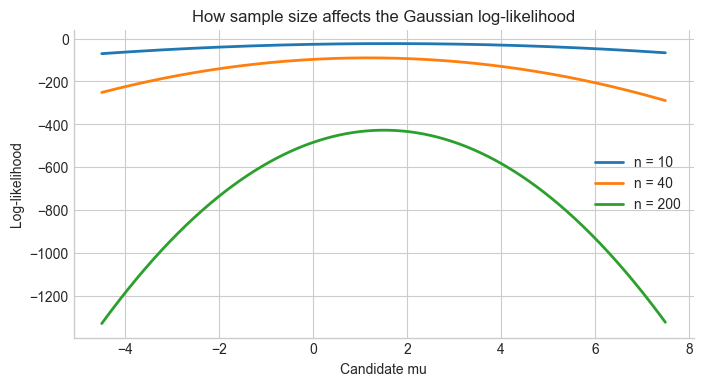

In [11]:
# Exercise 1 starter
sample_sizes = [10, 40, 200]
true_mu = 1.5
sigma = 2.0

for n in sample_sizes:
    data = rng.normal(loc=true_mu, scale=sigma, size=n)
    mu_grid = np.linspace(true_mu - 3 * sigma, true_mu + 3 * sigma, 400)
    log_likelihood = np.array([
        stats.norm.logpdf(data, loc=mu, scale=sigma).sum()
        for mu in mu_grid
    ])

    plt.plot(mu_grid, log_likelihood, lw=2, label=f"n = {n}")

plt.title("How sample size affects the Gaussian log-likelihood")
plt.xlabel("Candidate mu")
plt.ylabel("Log-likelihood")
plt.legend()
plt.show()

# Add 2-3 sentences below explaining what you observe.


### Exercise 2
Repeat the degrees-of-freedom experiment for $n = 3$, $5$, and $10$.
Check whether the center of $S_2$ matches the idea that it behaves like a chi-square variable with $n-1$ degrees of freedom.


In [12]:
# Exercise 2 starter
for n in [3, 5, 10]:
    samples = rng.normal(loc=0.0, scale=1.0, size=(40_000, n))
    s2 = np.sum((samples - samples.mean(axis=1, keepdims=True)) ** 2, axis=1)
    print(f"n = {n}, mean(S2) = {s2.mean():.3f}, expected = {n - 1}")

# Optional extension:
# Plot histograms for each n and compare them with the matching chi-square density.


n = 3, mean(S2) = 1.987, expected = 2
n = 5, mean(S2) = 4.005, expected = 4
n = 10, mean(S2) = 9.003, expected = 9


### Exercise 3
In the regression section, change the noise level $\sigma$.
Compare the fitted line and the error contour when the data are less noisy versus more noisy.


In [13]:
# Exercise 3 starter
true_beta0 = 2.0
true_beta1 = 0.8
x = np.linspace(0, 10, 35)

for sigma in [0.4, 1.2, 2.5]:
    y = true_beta0 + true_beta1 * x + rng.normal(0, sigma, size=len(x))
    X = np.column_stack([np.ones_like(x), x])
    beta0_hat, beta1_hat = np.linalg.lstsq(X, y, rcond=None)[0]
    print(f"sigma = {sigma:.1f} -> beta0_hat = {beta0_hat:.3f}, beta1_hat = {beta1_hat:.3f}")

# Optional extension:
# Recreate the contour plot for one low-noise and one high-noise setting.


sigma = 0.4 -> beta0_hat = 2.084, beta1_hat = 0.807
sigma = 1.2 -> beta0_hat = 2.325, beta1_hat = 0.806
sigma = 2.5 -> beta0_hat = 2.741, beta1_hat = 0.618
